# DCGAN on Fashion-MNIST — TensorFlow / Keras Version

**Assignment 4: Training a DCGAN on the Fashion-MNIST Dataset**

This notebook implements the same assignment using **TensorFlow and Keras**
instead of PyTorch, with its own architecture choices (different noise
dimension, layer sizes, and training-step structure using `tf.GradientTape`).

**The big idea:**
- The **Generator** turns a random noise vector into a fake clothing image.
- The **Discriminator** looks at an image and decides real vs. fake.
- They train against each other. Over time, the Generator gets better at
  producing realistic-looking clothing images.

On Colab: **Runtime > Change runtime type > GPU** before running, for speed.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

os.makedirs("grids_tf", exist_ok=True)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1: Settings

In [2]:
NOISE_DIM = 128          # size of the random noise vector
IMAGE_SIZE = 28           # keep native Fashion-MNIST size (no resize needed here)
BATCH_SIZE = 256
EPOCHS = 30               # assignment requires at least 25-30 epochs
SAVE_EVERY = 5
BUFFER_SIZE = 60000

## Step 2: Load and prepare the data

Fashion-MNIST comes bundled with Keras, so no manual download step is needed.
Pixel values are scaled to [-1, 1] to match the Generator's `tanh` output.

In [3]:
(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.reshape(-1, 28, 28, 1).astype("float32")
train_images = (train_images - 127.5) / 127.5  # scale to [-1, 1]

train_dataset = tf.data.Dataset.from_tensor_slices(train_images)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Step 3: The Generator

Uses `Conv2DTranspose` layers to go from a small dense projection up to a
full 28x28 image: 7x7 -> 14x14 -> 28x28.

In [4]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(NOISE_DIM,)),

        # Project noise vector into a small 7x7 feature map
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),

        # 7x7 -> 7x7 (refine features, no upsampling yet)
        layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 7x7 -> 14x14
        layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 14x14 -> 28x28, output 1 channel
        layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same",
                                use_bias=False, activation="tanh"),
    ])
    return model

generator = build_generator()
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,605,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,682,176 (10.23 MB)

 Trainable params: 2,656,704 (10.13 MB)

 Non-trainable params: 25,472 (99.50 KB)

## Step 4: The Discriminator

A standard CNN classifier, but with `Dropout` added (a design choice this
version uses that the PyTorch version didn't) to reduce overfitting to the
training batch and help stabilize training.

In [5]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # 28x28 -> 14x14
        layers.Conv2D(64, kernel_size=5, strides=2, padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        # 14x14 -> 7x7
        layers.Conv2D(128, kernel_size=5, strides=2, padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)   # raw logit, NOT sigmoid — handled by the loss function below
    ])
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Loss functions and optimizers

This version uses `BinaryCrossentropy(from_logits=True)`, which is the more
numerically stable way to do it in TensorFlow (the Discriminator outputs a
raw score instead of a 0-1 probability, and the loss function applies the
sigmoid internally).

In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator wants the discriminator to output "real" (1) for its fakes
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

# Fixed noise so we can watch the SAME 16 samples evolve across epochs
fixed_noise = tf.random.normal([16, NOISE_DIM], seed=42)

## Step 6: One training step

TensorFlow's `tf.GradientTape` records operations so gradients can be
computed automatically — this is the TF equivalent of PyTorch's
`.backward()`, but structured as one explicit function decorated with
`@tf.function` to compile it for speed.

In [7]:
@tf.function
def train_step(real_images):
    noise = tf.random.normal([tf.shape(real_images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

## Step 7: Helper to save a 4x4 image grid

In [8]:
def save_image_grid(epoch):
    predictions = generator(fixed_noise, training=False)
    predictions = (predictions + 1) / 2.0  # back to [0, 1] for display

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch}")
    plt.savefig(f"grids_tf/epoch_{epoch:03d}.png")
    plt.show()
    plt.close(fig)

## Step 8: Training loop

Epoch 1/30 | D loss: 1.349 | G loss: 0.674


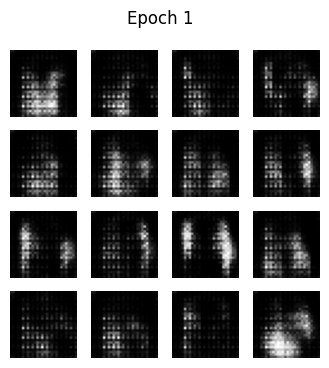

Epoch 2/30 | D loss: 1.375 | G loss: 0.712
Epoch 3/30 | D loss: 1.355 | G loss: 0.727
Epoch 4/30 | D loss: 1.309 | G loss: 0.762
Epoch 5/30 | D loss: 1.204 | G loss: 0.873


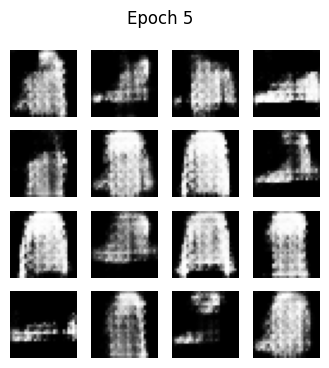

Epoch 6/30 | D loss: 1.170 | G loss: 0.922
Epoch 7/30 | D loss: 1.190 | G loss: 0.923
Epoch 8/30 | D loss: 1.237 | G loss: 0.883
Epoch 9/30 | D loss: 1.244 | G loss: 0.877
Epoch 10/30 | D loss: 1.274 | G loss: 0.843


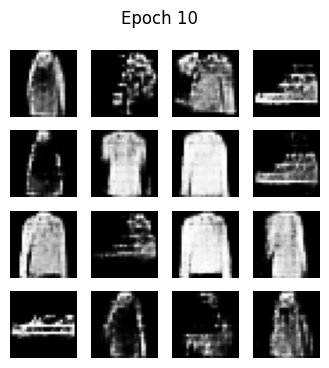

Epoch 11/30 | D loss: 1.233 | G loss: 0.895
Epoch 12/30 | D loss: 1.276 | G loss: 0.838
Epoch 13/30 | D loss: 1.286 | G loss: 0.824
Epoch 14/30 | D loss: 1.290 | G loss: 0.817
Epoch 15/30 | D loss: 1.236 | G loss: 0.892


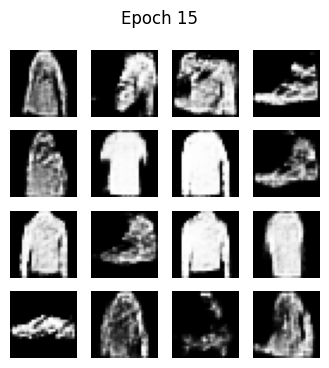

Epoch 16/30 | D loss: 1.286 | G loss: 0.817
Epoch 17/30 | D loss: 1.285 | G loss: 0.814
Epoch 18/30 | D loss: 1.293 | G loss: 0.808
Epoch 19/30 | D loss: 1.242 | G loss: 0.887
Epoch 20/30 | D loss: 1.282 | G loss: 0.825


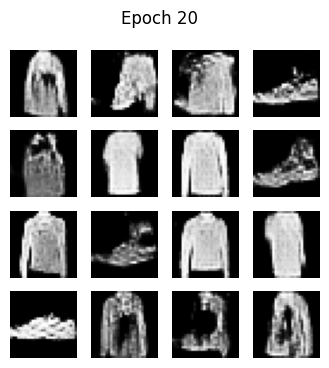

Epoch 21/30 | D loss: 1.296 | G loss: 0.807
Epoch 22/30 | D loss: 1.294 | G loss: 0.815
Epoch 23/30 | D loss: 1.306 | G loss: 0.801
Epoch 24/30 | D loss: 1.308 | G loss: 0.801
Epoch 25/30 | D loss: 1.312 | G loss: 0.799


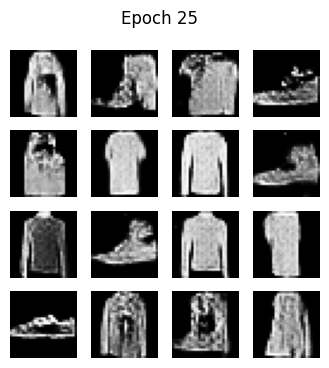

Epoch 26/30 | D loss: 1.305 | G loss: 0.804
Epoch 27/30 | D loss: 1.316 | G loss: 0.790
Epoch 28/30 | D loss: 1.319 | G loss: 0.789
Epoch 29/30 | D loss: 1.319 | G loss: 0.791
Epoch 30/30 | D loss: 1.314 | G loss: 0.797


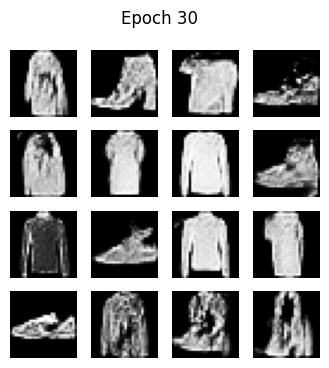

In [9]:
g_losses = []
d_losses = []

for epoch in range(1, EPOCHS + 1):
    epoch_g_loss = []
    epoch_d_loss = []

    for batch in train_dataset:
        g_loss, d_loss = train_step(batch)
        epoch_g_loss.append(g_loss.numpy())
        epoch_d_loss.append(d_loss.numpy())

    avg_g = float(np.mean(epoch_g_loss))
    avg_d = float(np.mean(epoch_d_loss))
    g_losses.append(avg_g)
    d_losses.append(avg_d)

    print(f"Epoch {epoch}/{EPOCHS} | D loss: {avg_d:.3f} | G loss: {avg_g:.3f}")

    if epoch % SAVE_EVERY == 0 or epoch == 1:
        save_image_grid(epoch)

## Step 9: Plot the losses

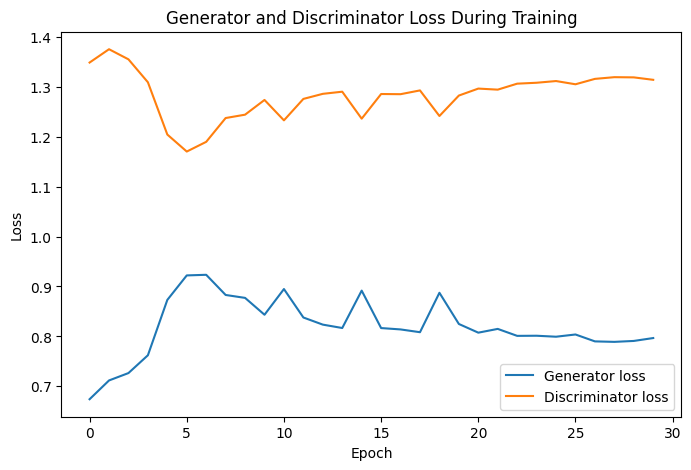

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(g_losses, label="Generator loss")
plt.plot(d_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss During Training")
plt.legend()
plt.savefig("grids_tf/loss_plot.png")
plt.show()

## Step 10: Written observations

Fill this in after inspecting your saved grids in `grids_tf/` and the loss plot above.

- **Early epochs (1-5):** Images look like random noise/static, no recognizable shapes yet.
- **Middle epochs (10-20):** Rough clothing silhouettes (shirts, trousers, shoes) begin to appear, often blurry or distorted.
- **Later epochs (25-30):** Look for sharper, more consistent shapes. Note whether:
  - Quality has **plateaued** (grids from epoch 25 and epoch 30 look nearly the same).
  - **Mode collapse** occurred (most or all of the 16 images look alike despite different noise).
  - Training was **unstable** (loss values spike or oscillate wildly instead of settling into a rhythm).
- **Note:** GAN losses don't need to decrease steadily like in normal supervised learning — oscillation between G and D loss is often a sign of balanced, healthy competition rather than a problem.